Epoch 1/25 | Train Loss: 0.6980 | Val Loss: 0.7062
Epoch 2/25 | Train Loss: 0.6963 | Val Loss: 0.7055
Epoch 3/25 | Train Loss: 0.6952 | Val Loss: 0.7047
Epoch 4/25 | Train Loss: 0.6940 | Val Loss: 0.7042
Epoch 5/25 | Train Loss: 0.6929 | Val Loss: 0.7037
Epoch 6/25 | Train Loss: 0.6919 | Val Loss: 0.7033
Epoch 7/25 | Train Loss: 0.6911 | Val Loss: 0.7029
Epoch 8/25 | Train Loss: 0.6900 | Val Loss: 0.7027
Epoch 9/25 | Train Loss: 0.6892 | Val Loss: 0.7025
Epoch 10/25 | Train Loss: 0.6884 | Val Loss: 0.7023
Epoch 11/25 | Train Loss: 0.6875 | Val Loss: 0.7021
Epoch 12/25 | Train Loss: 0.6866 | Val Loss: 0.7020
Epoch 13/25 | Train Loss: 0.6858 | Val Loss: 0.7019
Epoch 14/25 | Train Loss: 0.6850 | Val Loss: 0.7020
Epoch 15/25 | Train Loss: 0.6843 | Val Loss: 0.7019
Epoch 16/25 | Train Loss: 0.6834 | Val Loss: 0.7019
Epoch 17/25 | Train Loss: 0.6828 | Val Loss: 0.7019
Epoch 18/25 | Train Loss: 0.6819 | Val Loss: 0.7018
Epoch 19/25 | Train Loss: 0.6813 | Val Loss: 0.7019
Epoch 20/25 | Train L

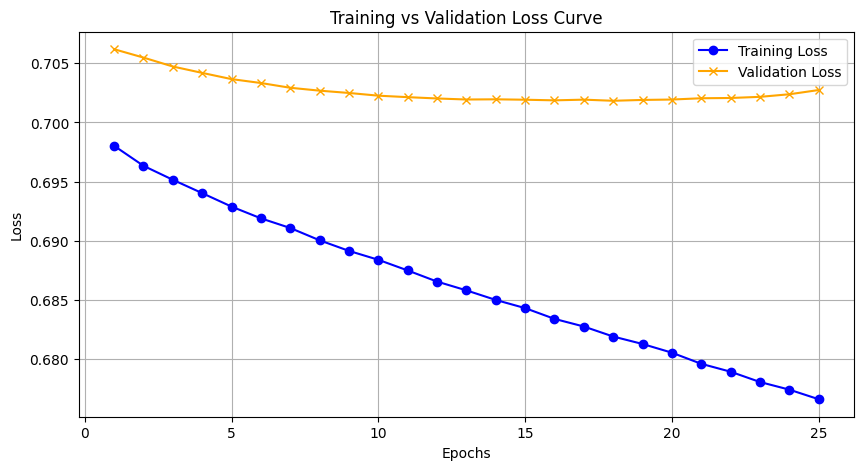

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Rule: Reproducibility ke liye random seed set karna lazmi hai
torch.manual_seed(42)

# --- 1. MONDAY'S ASSETS (Assuming your baseline tensors exist) ---
# Agar aapke paas tensors pehle se hain to unhe use karein. 
# For demonstration, hum X aur y dummy tensors bana rahe hain:
X_train_raw = torch.randn(500, 10)  # FloatTensor
y_train_raw = torch.randint(0, 2, (500,)).float()  # Binary classification ke liye

X_val_raw = torch.randn(100, 10)
y_val_raw = torch.randint(0, 2, (100,)).float()

# --- 2. DATALOADER ARCHITECTURE (Action 1) ---
train_dataset = TensorDataset(X_train_raw, y_train_raw)
val_dataset = TensorDataset(X_val_raw, y_val_raw)

# Training ke liye shuffle=True aur batch_size=64, validation un-shuffled
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# --- 3. MLP NETWORK & OPTIMIZER UPGRADE (Action 2) ---
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)  # Binary output
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x.squeeze()

# Model Instantiate karein
model = SimpleMLP(input_dim=10)

# Loss Function: Binary Cross Entropy with Logits
criterion = nn.BCEWithLogitsLoss()

# Advanced Optimizer: Adam with learning rate 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 4. MINI-BATCH LOOP EXECUTION (Action 3) ---
epochs = 25
train_losses = []
val_losses = []

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()               # Gradients clear karein
        predictions = model(batch_X)         # Forward pass
        loss = criterion(predictions, batch_y) # Loss calculation
        loss.backward()                     # Backpropagation
        optimizer.step()                    # Weights update
        
        running_train_loss += loss.item() * batch_X.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation Phase (Strictly without leaking gradients)
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            running_val_loss += loss.item() * batch_X.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

# --- 5. HYGIENE: DUAL-LINE PLOT ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='orange', marker='x')
plt.title('Training vs Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()